In [1]:
import numpy as np
import pandas as pd
import h5py
import os, sys
import torch
from transformers import AutoTokenizer
os.chdir('../../results/pseudo_gene/splice_junctions/')
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

In [2]:
junctions = ["start_sites", "stop_sites", "donor", "acceptor"]
cad2_suffixes = {
    "start_sites": "filtered_ATG",
    "stop_sites": "filtered_TAG", 
    "donor": "filtered_GT",
    "acceptor": "filtered_AG"
}

evo2_suffixes = {
    "start_sites": "evo2_7b_ntokens_3",
    "stop_sites": "evo2_7b_ntokens_3",
    "donor": "filtered_evo2_7b_ntokens_2",
    "acceptor": "filtered_evo2_7b_ntokens_2"
}

taxa = "B73_"
fnames_cad2 = [f"{taxa}{type}_{cad2_suffixes[type]}.h5" for type in junctions]
fnames_evo2 = [f"{taxa}{type}_{evo2_suffixes[type]}.npz" for type in junctions]
fnames_label = [f"{taxa}{type}_filtered_labels.tsv" for type in junctions]

In [3]:
def process_array_by_groups(arr, true_token_ids, group_size=3):
    tokenProb = []
    for row, token_id in zip(arr, true_token_ids):
        curToken = tokenizer.convert_ids_to_tokens(int(token_id))
        curProb = row[nucleotides.index(curToken)]
        tokenProb.append(curProb)
    
    avg_tokenProb = [np.mean(tokenProb[i:i+group_size]) for i in range(0, len(tokenProb), group_size)]
    return avg_tokenProb

def create_binary_labels(label):
    return 1 if label == "Core Gene" else 0

def chunks(lst, n):
    return [''.join(lst[i:i+n]).upper() for i in range(0, len(lst), n)]
    
tokenizer = AutoTokenizer.from_pretrained('kuleshov-group/PlantCaduceus_l32')

In [4]:
labels_dict = {}
nucleotides = list('acgt')
for idx, junction in enumerate(junctions):
    label = pd.read_csv(fnames_label[idx], sep='\t')
    
    # load plantcad2 logits
    with h5py.File(fnames_cad2[idx], 'a') as hf:
        plantcad2_logits = torch.tensor(hf['predicted_logits'][:])
        true_ids = torch.tensor(hf['true_token_ids'][:])

    plantcad2_logits = plantcad2_logits[:, [tokenizer.get_vocab()[nc] for nc in nucleotides]] # only retain atcg
    plantcad2_logits = torch.tensor(plantcad2_logits)
    plantcad2_probs = torch.nn.functional.softmax(plantcad2_logits, dim=1).numpy()

    # load evo2 logits
    loaded = np.load(fnames_evo2[idx])
    evo_probs = loaded['logits']
    evo_probs_reshaped = evo_probs.reshape(-1, 4)
    
    if junction in ['start_sites', 'stop_sites']:
        plantcad2_scores = process_array_by_groups(plantcad2_probs, true_ids, group_size=3)
        evo2_scores = process_array_by_groups(evo_probs_reshaped, true_ids, group_size=3)
    else:
        plantcad2_scores = process_array_by_groups(plantcad2_probs, true_ids, group_size=2)
        evo2_scores = process_array_by_groups(evo_probs_reshaped, true_ids, group_size=2)

    label['predicted_plantcad2'] = plantcad2_scores
    label['predicted_evo2'] = evo2_scores
    labels_dict[junction] = label

/tmp/ipykernel_1221521/1620971698.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plantcad2_logits = torch.tensor(plantcad2_logits)
/tmp/ipykernel_1221521/1620971698.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plantcad2_logits = torch.tensor(plantcad2_logits)
/tmp/ipykernel_1221521/1620971698.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plantcad2_logits = torch.tensor(plantcad2_logits)
/tmp/ipykernel_1221521/1620971698.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().

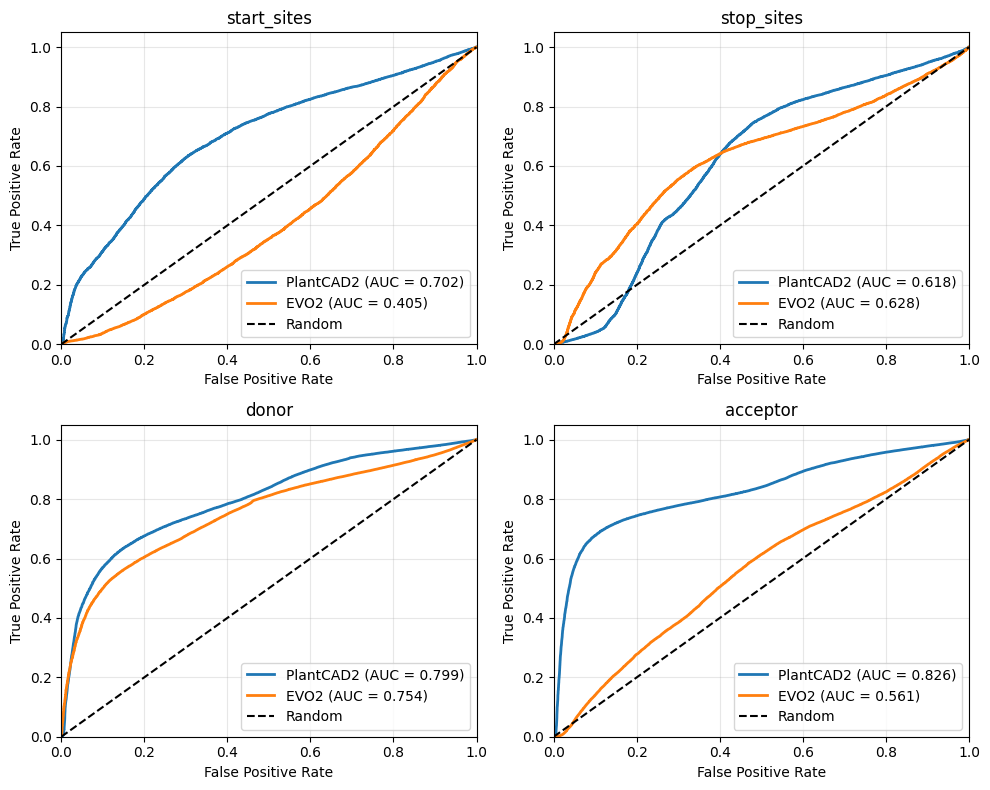

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes_flat = axes.flatten()

for idx, (dataset_name, df) in enumerate(labels_dict.items()):
    ax = axes_flat[idx]
    
    subsets = df[df['Label'] != 'Near-Core Gene'].copy()
    subsets['binary_label'] = subsets['Label'].apply(create_binary_labels)
    y_true = subsets['binary_label'].values
    y_scores_cad2 = subsets['predicted_plantcad2'].values
    y_scores_evo2 = subsets['predicted_evo2'].values

    fpr_cad2, tpr_cad2, _ = roc_curve(y_true, y_scores_cad2)
    fpr_evo2, tpr_evo2, _ = roc_curve(y_true, y_scores_evo2)
    
    roc_auc_cad2 = auc(fpr_cad2, tpr_cad2)
    roc_auc_evo2 = auc(fpr_evo2, tpr_evo2)

    ax.plot(fpr_cad2, tpr_cad2, 
           label=f'PlantCAD2 (AUC = {roc_auc_cad2:.3f})',
           color='C0', linewidth = 2)
    ax.plot(fpr_evo2, tpr_evo2, 
           label=f'EVO2 (AUC = {roc_auc_evo2:.3f})',
           color='C1', linewidth = 2)
    
    ax.plot([0, 1], [0, 1], 'k--', label='Random')
    
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{dataset_name}')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])

plt.tight_layout()

plt.savefig('../../../pipelines/pseudo_gene/Core_noncore_classification.pdf', format='pdf',bbox_inches='tight')

plt.show()